<a href="https://colab.research.google.com/github/ChristineHarvey/InformationLossScore/blob/main/8multiclinsum_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


MULTICLINSUM INFORMATION LOSS ANALYSIS SCORE


End-to-end NLP pipeline for measuring information loss between Full Clinical Reports and their associated Clinical Summaries, using the MultiClinSum v8 dataset.


PIPELINE


0. Installation and imports
1. Data ingestion
2. preprocessing
5. Embedding generation (and testing)
4. Clinical NER extraction (and testing)
5. Metric computation and Final Information Loss Score
6. Analysis of results
7. Visualisation
8. Export results


EXPECTED DATASET STRUCTURE


project_folder/

    multiclinsum_large-scale_train_en/
        fulltext/
            multiclinsum_ls_en_1.txt
            ...
        summaries/
            multiclinsum_ls_en_1_sum.txt
            ...

    multiclinsum_gs_train_en/
        fulltext/
        summaries/

    multiclinsum_test_en/
        fulltext/
        summaries/

In [5]:
#====================================================================
# 0 - INSTALLATION
#====================================================================
!pip install transformers==4.30.0

!pip install pandas numpy matplotlib scikit-learn scipy
!pip install transformers sentence-transformers
!pip install rouge-score bert-score
#!pip install stanza

# ==================================================================
# 0 - IMPORTS
# ==================================================================

import os
import glob
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### models ####
from transformers import pipeline  #for NER
from sentence_transformers import SentenceTransformer  #for embedding generation

#### metrics ####
from sklearn.metrics.pairwise import cosine_similarity
from rouge_score import rouge_scorer
from bert_score import score as bertscore
from sklearn.feature_extraction.text import CountVectorizer  #in JS-divergence
from scipy.spatial.distance import jensenshannon
from collections import Counter #in Entropy Loss
from scipy.stats import entropy
#or from sklearn.metrics import normalized_mutual_info_score


  Using cached transformers-4.30.0-py3-none-any.whl.metadata (113 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.30.0-py3-none-any.whl (7.2 MB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (tokenizers)


In [6]:
#mount folder
from google.colab import drive
drive.mount('/content/drive/', force_remount=True)

#start with MultiClinSum/multiclinsum_gs_train_en/ as prototype
!cp -r "/content/drive/MyDrive/MultiClinSum/multiclinsum_gs_train_en/" /content/
print("drive connected to colab")

# ==================================================================
# 1 - DATA INGESTION
# ==================================================================

def load_multiclinsum_dataset(base_folder, dataset_name):
    """
    Loads report-summary pairs from MultiClinSum
    """
    fulltext_folder = os.path.join(base_folder, "fulltext")
    summary_folder = os.path.join(base_folder, "summaries")

    data = []

    report_files = glob.glob(os.path.join(fulltext_folder, "*.txt"))

    print(f"Loading dataset: {dataset_name}")
    print(f"Found {len(report_files)} reports")

    for report_path in report_files:
        report_filename = os.path.basename(report_path)
        # remove .txt
        report_id = report_filename.replace(".txt", "")
        # create matching summary filename
        summary_filename = f"{report_id}_sum.txt"
        summary_path = os.path.join(summary_folder, summary_filename)

        # skip if missing summary
        if not os.path.exists(summary_path):
            print(f"WARNING: Missing summary -> {report_id}")
            continue

        # read report
        with open(report_path, "r", encoding="utf-8") as f:
            report_text = f.read()

        # read summary
        with open(summary_path, "r", encoding="utf-8") as f:
            summary_text = f.read()

        data.append({
            "dataset": dataset_name,
            "report_id": report_id,
            "report_text": report_text,
            "summary_text": summary_text
        })
    return pd.DataFrame(data)

DATASET_FOLDERS = {
  "gold_standard": "/content/multiclinsum_gs_train_en" #,
  #"large_scale": "multiclinsum_large-scale_train_en",
  #"test": "/content/MultiClinSum/multiclinsum_test_en"
}
all_dfs = []

for dataset_name, folder_path in DATASET_FOLDERS.items():
    if os.path.exists(folder_path):
        dataset_df = load_multiclinsum_dataset(folder_path, dataset_name)
        all_dfs.append(dataset_df)
    else:
        print(f"WARNING: Folder not found -> {folder_path}")

# combine
df = pd.concat(all_dfs, ignore_index=True)

print("Total samples:", len(df))
print("Dataset counts:")
print(df["dataset"].value_counts())


# ==================================================================
# 2 - DATA PREPROCESSING
# ==================================================================

def preprocess_text(text):
    """
    Basic preprocessing
    """
    text = str(text)
    # lowercase
    text = text.lower()
    # remove extra spaces
    text = re.sub(r"\s+", " ", text)
    # replace curly '
    #text = text.replace("’", "'")
    # remove special characters
    #text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    return text.strip()

print("Preprocessing text")

df["report_clean"] = df["report_text"].apply(preprocess_text)
df["summary_clean"] = df["summary_text"].apply(preprocess_text )

def remove_duplicate_sentences(text):
    sentences = text.strip().split(". ")
    # or sentences = re.split(r'\. ', text.strip())
    return ". ".join(dict.fromkeys(sentences))

df["report_deduplicated"] = df["report_clean"].apply(remove_duplicate_sentences)
df["summary_deduplicated"] = df["summary_clean"].apply(remove_duplicate_sentences)

# Find texts that were changed
changed = df[
    (df["report_clean"] != df["report_deduplicated"]) |
    (df["summary_clean"] != df["summary_deduplicated"])
    ]

print("Preprocessing complete")

# Select columns to export
changed_export = changed[
    [   "report_id",
        "report_clean",
        "report_deduplicated",
        "summary_clean",
        "summary_deduplicated"
    ]
]

# Save to CSV
changed_export.to_csv("changed_reports.csv", index=False)

Mounted at /content/drive/
drive connected to colab
Loading dataset: gold_standard
Found 592 reports
Total samples: 592
Dataset counts:
dataset
gold_standard    592
Name: count, dtype: int64
Preprocessing text
Preprocessing complete


In [ ]:
# # ==================================================================
# # 2 - LOAD MODELS
# # ==================================================================

# print("Loading models...")

# #creating nlp model from spacy using pre-trained pipeline for English
# ##nlp = spacy.load("en_core_web_sm")

# #alternatively used STANZA to create nlp model
# #nlp_stanza = stanza.Pipeline('en', processors='tokenize,ner')

# #creating basic baseline embedding model from SentenceTransformer
# ##embedding_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# #creating Biomedical embeddings from the PubMedBERT-base-embeddings model fined-tuned using sentence-transformers
# embedding_biomed = SentenceTransformer("neuml/biomedbert-base-embeddings")
# ##embedding_biomed = SentenceTransformer("sentence-transformers/BiomedNLP/PubMedBERT-base-uncased-abstract-fulltext")

# print("Models loaded")


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/283 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/5.96k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/312 [00:00<?, ?B/s]

Models loaded


Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

Embeddings generated.
embeddings shape (592, 768)


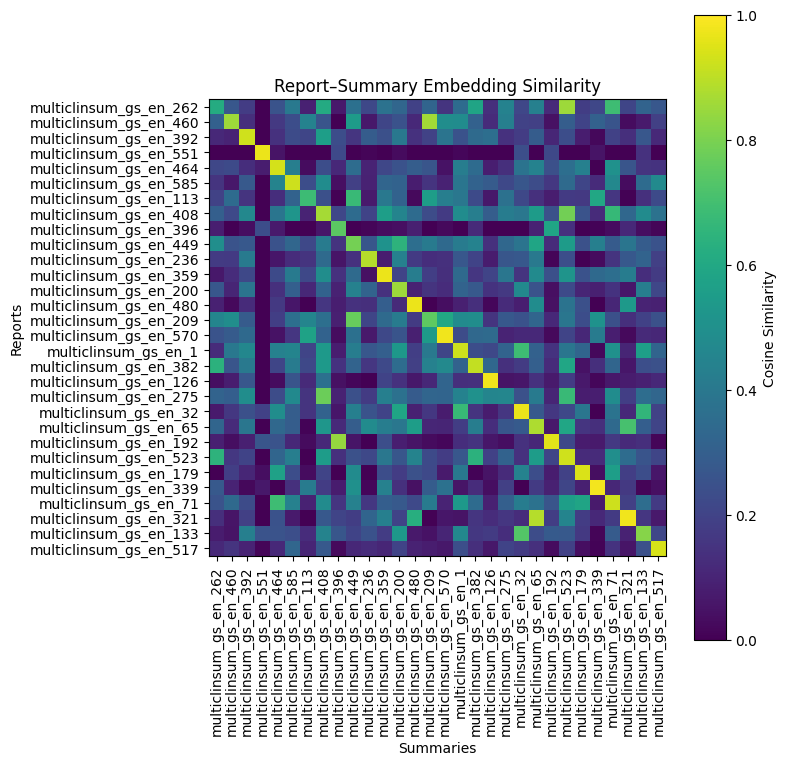

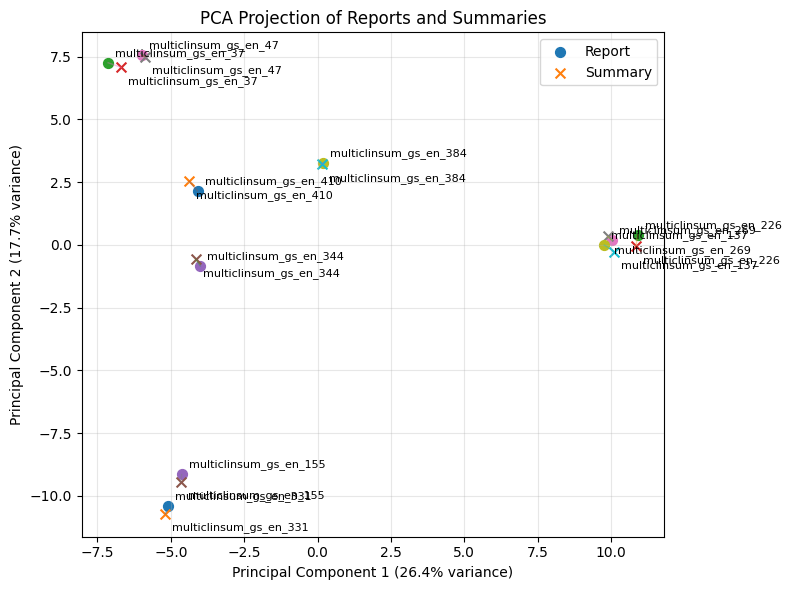

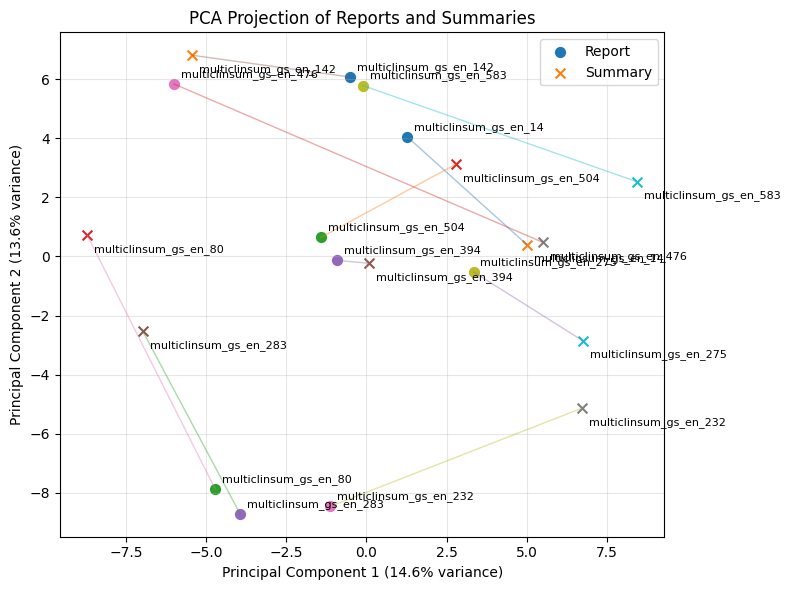

Empty DataFrame
Columns: [report_id, wordcount_diff]
Index: []


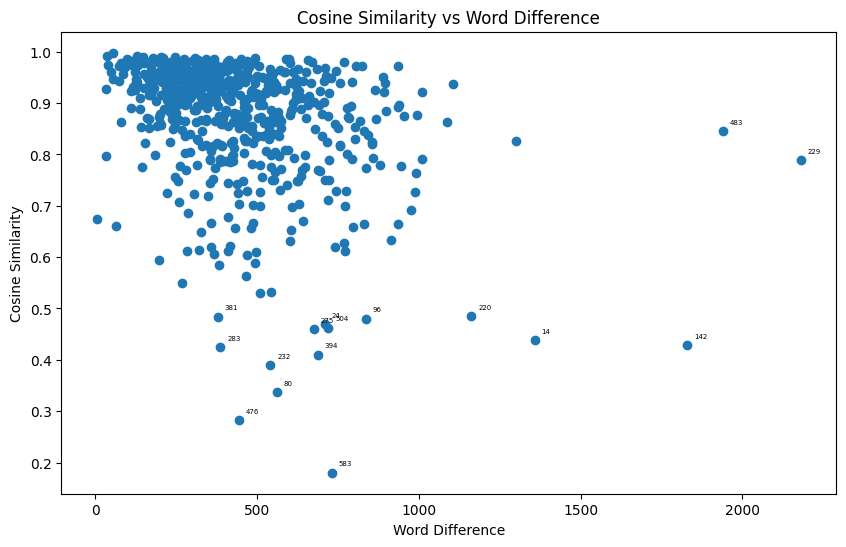

Report ID: multiclinsum_gs_en_339
Cosine similarity: 0.9837

REPORT:
we describe a case of 18‐year‐old male patient, affected by dmd and in a wheelchair from the age of 11, who has always been followed up by a multidisciplinary team in our institution. since the age of six, he was treated by oral medication with deflazacort. during these years, the patient was regularly followed up by pneumologists by using with spirometry and by neurologists who monitored the evolution of the neuromuscular disease in terms of thoraco‐abdominal function and scoliosis. forced vital capacity (fvc), forced expiratory volume in 1 s (fev1), and peak expiratory flow (pef) were, respectively, 60%, 70%, and 70% of predicted values (fvc, 2.24 lt; fev1, 2.09 lt; pef, 4.07 lt). the patient also underwent right‐heart catheterization to monitor pulmonary vascular resistances with evidence of values within normal range. when he progressively developed dilated cardiomyopathy in 2016, at the age of 14, he underwent he

In [7]:
# ==================================================================
# 3 - EMBEDDING GENERATION biomedical
# ==================================================================

#creating Biomedical embeddings from the PubMedBERT-base-embeddings model fined-tuned using sentence-transformers
embedding_biomed = SentenceTransformer("neuml/biomedbert-base-embeddings")
##embedding_biomed = SentenceTransformer("sentence-transformers/BiomedNLP/PubMedBERT-base-uncased-abstract-fulltext")
print("Models loaded")

report_embeddings = embedding_biomed.encode(
    df["report_deduplicated"].tolist(),
    show_progress_bar=True
)

summary_embeddings = embedding_biomed.encode(
    df["summary_deduplicated"].tolist(),
    show_progress_bar=True
)

print("Embeddings generated.")

print("embeddings shape", report_embeddings.shape)  #384-dim vector from all-MiniLM-L6-v2


# ==================================================================
# CHECKING EMBEDDINGS (using similarity matrix of random 30 reports)
# ==================================================================

# take 30 random embeddings
np.random.seed(222)
random_indices = np.random.choice(len(report_embeddings), size=30, replace=False)
report_emb_30 = report_embeddings[random_indices]
summary_emb_30 = summary_embeddings[random_indices]

# create a similarity matrix
similarity_matrix = cosine_similarity(report_emb_30, summary_emb_30)

# visualise heatmap of similarity matrix
plt.figure(figsize=(8, 8))
plt.imshow(similarity_matrix, cmap="viridis", vmin=0, vmax=1)
plt.xlabel("Summaries")
plt.ylabel("Reports")

plt.xticks(range(30), df["report_id"].iloc[random_indices], rotation=90)
plt.yticks(range(30), df["report_id"].iloc[random_indices])
plt.title("Report–Summary Embedding Similarity")
plt.colorbar(label="Cosine Similarity")
plt.tight_layout()
plt.show()

# ==================================================================
# CHECKING EMBEDDINGS (using PCA and visualisation)
# ==================================================================

def plotPCA(report_embeddings, summary_embeddings, report_ids):
  from sklearn.decomposition import PCA

  # Combine report and summary embeddings
  combined_embeddings = np.vstack([report_embeddings, summary_embeddings])

  # Fit PCA jointly
  pca = PCA(n_components=2)
  combined_2d = pca.fit_transform(combined_embeddings)

  # Split the PCA results back into reports and summaries
  len_reports = len(report_embeddings)
  report_2d = combined_2d[:len_reports]
  summary_2d = combined_2d[len_reports:]

  # Create paired plot
  plt.figure(figsize=(8, 6))
  for i in range(len_reports):
      # Coordinates
      report_x, report_y = report_2d[i]
      summary_x, summary_y = summary_2d[i]

      # original report_id
      report_id = report_ids[i]

      # Plot report and summary points
      plt.scatter(report_x, report_y, marker="o", s=50)
      plt.scatter(summary_x, summary_y, marker="x", s=50 )

      # Draw line connecting report and summary
      plt.plot( [report_x, summary_x], [report_y, summary_y], alpha=0.4, linewidth=1 )

      # Label with prefix R for report and S for summary
      plt.annotate( report_id, (report_x, report_y), xytext=(5, 5), textcoords="offset points", fontsize=8  )
      plt.annotate( report_id, (summary_x, summary_y), xytext=(5, -12), textcoords="offset points", fontsize=8  )

  # Labels and formatting
  plt.xlabel(f"Principal Component 1 "
      f"({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")

  plt.ylabel(f"Principal Component 2 "
      f"({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")

  plt.title("PCA Projection of Reports and Summaries")
  plt.grid(True, alpha=0.3)
  plt.scatter([], [], marker="o", s=50, label="Report")
  plt.scatter([], [], marker="x", s=50, label="Summary")
  plt.legend()
  plt.tight_layout()
  plt.show()

# ==================================================================
# CHECKING ALL EMBEDDINGS (find top-10 and bottom-10 cosine similarity)
# ==================================================================

# create a similarity matrix overall all the data
similarity_all = cosine_similarity(report_embeddings, summary_embeddings)
paired_similarity = np.diag(similarity_all)   #1D array of cosine similarity between pairs

report_ids = df["report_id"].values
results = pd.DataFrame({
    "report_id": report_ids,
    "cosine_similarity": paired_similarity
})

top_10 = results.nlargest(10, "cosine_similarity")
bottom_10 = results.nsmallest(10, "cosine_similarity")

# inspect top and bottom content/text

def print_pair(res):
  for _, row in res.iterrows():
    report_id = row["report_id"]
    case = df[df["report_id"] == report_id].iloc[0]

    print("=" * 80)
    print(f"Report ID: {report_id}")
    print(f"Cosine similarity: {row['cosine_similarity']:.4f}")

    print("\nREPORT:")
    print(case["report_deduplicated"])

    print("\nSUMMARY:")
    print(case["summary_deduplicated"])


#### Plot PCA for top_10 cosine similarities ####

# Get report IDs from top_10
top_ids = top_10["report_id"].values

# Find POSITION of each report in the DataFrame
top_indices = np.where(df["report_id"].isin(top_ids))[0]

# Get the corresponding embeddings
top_report_embeddings = report_embeddings[top_indices]
top_summary_embeddings = summary_embeddings[top_indices]

# Make sure IDs are in the same order as the embeddings
top_ids = df["report_id"].iloc[top_indices].values

# Plot PCA for top_10 cosine similarities
plotPCA(
    top_report_embeddings,
    top_summary_embeddings,
    top_ids
)

#### Plot PCA for bottom_10 cosine similarities ####

# Get report IDs from bottom_10
bot_ids = bottom_10["report_id"].values

# Find POSITION of each report in the DataFrame
bot_indices = np.where(df["report_id"].isin(bot_ids))[0]

# Get the corresponding embeddings
bottom_report_embeddings = report_embeddings[bot_indices]
bottom_summary_embeddings = summary_embeddings[bot_indices]

# Make sure IDs are in the same order as the embeddings
bot_ids = df["report_id"].iloc[bot_indices].values
# Plot PCA for bottom_10 cosine similarities
plotPCA(
    bottom_report_embeddings,
    bottom_summary_embeddings,
    bot_ids
)

# ==================================================================
# CHECKING ALL EMBEDDINGS (word counts vs cosine similarity)
# ==================================================================

#### explore if cosine similarity is proportional to word count similarity ####
#### does higher cosine similarity exist between documents of a similar size? ####

#make a dataframe that has the report_ids and word counts of report_deduplicated and summary_deduplicated
df_wordcounts = df[["report_id", "report_deduplicated", "summary_deduplicated"]].copy()
df_wordcounts["report_word_count"] = df_wordcounts["report_deduplicated"].apply(lambda x: len(x.split()))
df_wordcounts["summary_word_count"] = df_wordcounts["summary_deduplicated"].apply(lambda x: len(x.split()))
df_wordcounts = df_wordcounts.drop(columns=["report_deduplicated", "summary_deduplicated"])
df_wordcounts["wordcount_diff"] = df_wordcounts["report_word_count"] - df_wordcounts["summary_word_count"]
df_wordcounts = df_wordcounts.drop(columns=["report_word_count", "summary_word_count"])
df_wordmerge = pd.merge(results, df_wordcounts, on="report_id")
df_wordmerge = df_wordmerge.sort_values(by="cosine_similarity", ascending=False)

#find any negative word count differences, in case summary not shorter
print(df_wordmerge.loc[df_wordmerge["wordcount_diff"] <= 0, ["report_id", "wordcount_diff"]])

#to simplify labels and select only a few datapoints to label
df_wordmerge["plot_report_id"] = (df_wordmerge["report_id"].str.replace("multiclinsum_gs_en_", "", regex=False))
df_label_rows = df_wordmerge[(df_wordmerge["cosine_similarity"] < 0.5) | (df_wordmerge["wordcount_diff"] > 1500)]

#plot a graph to visualise relationship
plt.figure(figsize=(10, 6))
plt.scatter(df_wordmerge["wordcount_diff"], df_wordmerge["cosine_similarity"])

#add report_id labels
for _, row in df_label_rows.iterrows():
    plt.annotate(
        row["plot_report_id"],
        (row["wordcount_diff"], row["cosine_similarity"]),
        fontsize=5,
        xytext=(5, 5),
        textcoords="offset points"
    )
plt.xlabel("Word Difference")
plt.ylabel("Cosine Similarity")
plt.title("Cosine Similarity vs Word Difference")
plt.show()


# ==================================================================
# CHECKING ALL EMBEDDINGS (quantile sampling to find 20 evenly distributed samples)
# ==================================================================

#create a similarity matrix overall all the data
similarity_all = cosine_similarity(report_embeddings, summary_embeddings)
paired_similarity = np.diag(similarity_all)

report_ids = df["report_id"].values
results = pd.DataFrame({
    "report_id": report_ids,
    "report_deduplicated": df["report_deduplicated"],
    "summary_deduplicated": df["summary_deduplicated"],
    "cosine_similarity": paired_similarity
})

#sort descending
results_sorted = results.sort_values("cosine_similarity",ascending=False).reset_index(drop=True)

#create 20 equally sized groups based on cosine similarity
results_sorted["bin"] = pd.qcut(
    results_sorted["cosine_similarity"],
    q=20,
    labels=False,
    duplicates="drop"
)

#randomly select one report from each bin
sample_20 = (
    results_sorted
    .groupby("bin", group_keys=False)
    .sample(n=1, random_state=222)
    .sort_values("cosine_similarity", ascending=False)
    .reset_index(drop=True)
)

print_pair(sample_20)

#output sample_20 for human ranking
OUTPUT_FILE = "sample_20.csv"
sample_20.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)


In [8]:
# ==================================================================
# 4 - CLINICAL NER EXTRACTION with Glasgow-AI4BioMed/bioner_medmentions_st21pv
# ==================================================================

#https://huggingface.co/Glasgow-AI4BioMed/bioner_medmentions_st21pv

#load pretrained BiomedBERT finetuned for NER using MedMentions dataset
MODEL_NAME = "Glasgow-AI4BioMed/bioner_medmentions_st21pv"

ner_pipeline = pipeline(
    "token-classification",
    model=MODEL_NAME,
    aggregation_strategy="simple"
)
print(ner_pipeline.model.config.id2label) # to see lebels

#reuse the tokenizer already in NER pipeline
tokenizer = ner_pipeline.tokenizer

def extract_entities(text):
  """
  Extracts clinical named entities (NERs) using BiomedBERT.
  Uses overlapping chunks as some reports are over 512 tokens (BiomedBERT's max).
  """

  #convert text into tokens to pass to the BioClinicalBERT
  tokens = tokenizer(
    text,
    add_special_tokens=False,  #prevent these during chunking
    truncation=False,  #prevents long reports being truncated
    return_offsets_mapping=True
   )

  input_ids = tokens["input_ids"]  #numerical token IDs created by tokeniser
  offsets = tokens["offset_mapping"] #offset of token in original string

  #set chunk size and overlap
  max_tokens = 500  #to allow for max512-special tokens
  overlap = 50  #to reduce splitting a clinical entitiy across chunks
  entities = []

  #process into chunks and extract entities
  start = 0   #first token
  while start < len(input_ids):
    #work out where the chunk ends
    end = min(start + max_tokens, len(input_ids))

    #extracts character positions of this token in the ORIGINAL text
    chunk_start_char = offsets[start][0]
    chunk_end_char = offsets[end-1][1]

    #extract original text rather than decoding token IDs
    chunk_text = text[chunk_start_char:chunk_end_char]

    results = ner_pipeline(chunk_text)

    for entity in results:
      ent_start = entity["start"]
      ent_end = entity["end"]

      ## THIS  to fix well-circumscribed ##
      # Start with the model's predicted boundaries
      word_start = ent_start
      word_end = ent_end

      # Expand backwards if prediction starts part-way through a word
      while (word_start > 0 and (chunk_text[word_start - 1].isalnum() or chunk_text[word_start - 1] in "-’'")):
        word_start -= 1

      # Expand forwards if prediction ends part-way through a word
      while (word_end < len(chunk_text) and (chunk_text[word_end].isalnum() or chunk_text[word_end] in "-’'")):
        word_end += 1

      # Extract exact text from original chunk
      word = chunk_text[word_start:word_end]
      ##word = entity["word"]

      ## OR THIS to fix sceptism ##

      #fix missing part before hyphen.
      if word.lstrip().startswith("-"):
        #move backwards to beginning of complete word
        word_start = ent_start
        #check if still a letter, number, hyphen or apostrophe
        while (word_start > 0 and (chunk_text[word_start-1].isalnum() or chunk_text[word_start-1] in "-’")):
          word_start -= 1
        word = chunk_text[word_start:ent_end]
      #fix missing part after hyphen.
      elif word.rstrip().endswith("-"):
        word_end = ent_end
        #move forwards through the rest of the word
        while (word_end < len(chunk_text) and (chunk_text[word_end].isalnum() or chunk_text[word_end] in "-’")):
          word_end += 1
        word = chunk_text[ent_start:word_end]

    ## END ##
      entities.append(word.strip())

    #move forward, keeping overlap
    start += max_tokens - overlap
  return list(dict.fromkeys(entities))  #removes duplicates and preserved order

print("Extracting entities")

df_BioNER = df[["report_id", "report_deduplicated", "summary_deduplicated"]].copy()
df_BioNER["report_entities"] = (df_BioNER["report_deduplicated"].apply(extract_entities))
df_BioNER["summary_entities"] = (df_BioNER["summary_deduplicated"].apply(extract_entities))

print("NER extraction complete")

# ==================================================================
# CHECKING NER EXTRACTION with Glasgow-AI4BioMed/bioner_medmentions_st21pv
# ==================================================================

#extract only sample_20 rows from entities in df_BioNER
# df_BioNER_analysis = df_BioNER[
#     df_BioNER["report_id"].isin(sample_20["report_id"])
# ].copy()

df_BioNER_analysis = (
    df_BioNER.set_index("report_id")
    .loc[sample_20["report_id"]]
    .reset_index()
)

#count the report entities
df_BioNER_analysis["report_entity_count"] = (df_BioNER_analysis["report_entities"].apply(len))

#output entities to compare
OUTPUT_FILE = "BioNER_analysis.csv"
df_BioNER_analysis.to_csv(OUTPUT_FILE, index=False, encoding="utf-8-sig")
print("RESULTS SAVED as", OUTPUT_FILE)

print(df_BioNER_analysis)


config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  436MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.26k [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1482 > 512). Running this sequence through the model will result in indexing errors


{0: 'O', 1: 'B-Anatomy', 2: 'I-Anatomy', 3: 'B-Chemicals & Drugs', 4: 'I-Chemicals & Drugs', 5: 'B-Concepts & Ideas', 6: 'I-Concepts & Ideas', 7: 'B-Devices', 8: 'I-Devices', 9: 'B-Disorders', 10: 'I-Disorders', 11: 'B-Genes & Molecular Sequences', 12: 'I-Genes & Molecular Sequences', 13: 'B-Geographic Areas', 14: 'I-Geographic Areas', 15: 'B-Living Beings', 16: 'I-Living Beings', 17: 'B-Objects', 18: 'I-Objects', 19: 'B-Occupations', 20: 'I-Occupations', 21: 'B-Organizations', 22: 'I-Organizations', 23: 'B-Phenomena', 24: 'I-Phenomena', 25: 'B-Physiology', 26: 'I-Physiology', 27: 'B-Procedures', 28: 'I-Procedures'}
Extracting entities


[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


NER extraction complete
RESULTS SAVED as BioNER_analysis.csv
                 report_id                                report_deduplicated  \
0   multiclinsum_gs_en_339  we describe a case of 18‐year‐old male patient...   
1    multiclinsum_gs_en_59  a 2-year-old female presented with a 1-year hi...   
2    multiclinsum_gs_en_32  this is the case of a 36-year-old woman from t...   
3   multiclinsum_gs_en_461  a 67-year-old woman with dilated cardiomyopath...   
4    multiclinsum_gs_en_34  68-year-old man with hypertension, chronic obs...   
5   multiclinsum_gs_en_356  40-year-old woman with a history of mood disor...   
6   multiclinsum_gs_en_230  a black male infant weighing 2,021 g was born ...   
7   multiclinsum_gs_en_140  the authors have read the case report (care) c...   
8   multiclinsum_gs_en_429  40-year-old male presented with a 2-month hist...   
9    multiclinsum_gs_en_95  clinical presentation a 68-year-old chinese fe...   
10   multiclinsum_gs_en_23  nine-year-old male s

In [11]:
# ==================================================================
# 5 - METRIC COMPUTATION
# ==================================================================

# ------------------------------------------------------------------
# ROUGE-L
# ------------------------------------------------------------------

rouge_precision = []
rouge_recall = []
rouge_f1 = []

#creates rouge baseline score using roberta-large default
rouge_scorer_model = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

for report, summary in zip(df["report_deduplicated"], df["summary_deduplicated"]):
    score = rouge_scorer_model.score(report, summary)["rougeL"]

    rouge_precision.append(score.precision)
    rouge_recall.append(score.recall)
    rouge_f1.append(score.fmeasure)

df["ROUGE_L_P"] = rouge_precision
df["ROUGE_L_R"] = rouge_recall
df["ROUGE_L_F1"] = rouge_f1

print("ROUGE-L completed")

# ------------------------------------------------------------------
# BERTScore
# ------------------------------------------------------------------

#calculate basic BERTscore using roberta-large default
P, R, F1 = bertscore(
    df["summary_deduplicated"].tolist(),
    df["report_deduplicated"].tolist(),
    lang="en",
    verbose=True
)
df["BERTScore_P"] = P.numpy()
df["BERTScore_R"] = R.numpy()
df["BERTScore_F1"] = F1.numpy()
print("Basic BERTScore completed")

#calculate biomedical BERTscore using BiomedBERT fine-tuned on MedMentions
bioP, bioR, bioF1 = bertscore(
    df["summary_deduplicated"].tolist(),
    df["report_deduplicated"].tolist(),
    model_type="neuml/biomedbert-base-embeddings",
    num_layers=12,
    verbose=True
)
df["BiomedBERTScore_P"] = bioP.numpy()
df["BiomedBERTScore_R"] = bioR.numpy()
df["BiomedBERTScore_F1"] = bioF1.numpy()
print("BiomedBERTScore completed")

# ------------------------------------------------------------------
# ENTITY RECALL + ENTITY LOSS
# ------------------------------------------------------------------

def compute_entity_recall(report_entities, summary_entities):
    report_set = set(report_entities)
    summary_set = set(summary_entities)
    if len(report_set) == 0:
        return 0
    overlap = report_set.intersection(summary_set)
    return len(overlap) / len(report_set)

entity_recalls = []

for report_entities, summary_entities in zip(df_BioNER["report_entities"], df_BioNER["summary_entities"]):
    recall = compute_entity_recall(report_entities, summary_entities)
    entity_recalls.append(recall)
df["Entity_Recall"] = entity_recalls

# NB information loss
df["NER_Loss"] = 1 - df["Entity_Recall"]
print("Entity loss completed")

# ------------------------------------------------------------------
# JENSEN-SHANNON DIVERGENCE
# ------------------------------------------------------------------

vectorizer = CountVectorizer(stop_words="english")

def compute_js_divergence(text1, text2):
    vectors = vectorizer.fit_transform( [text1, text2] )
    v1 = vectors.toarray()[0] + 1e-10
    v2 = vectors.toarray()[1] + 1e-10
    p = v1 / np.sum(v1)
    q = v2 / np.sum(v2)
    return jensenshannon(p, q)

js_scores = []

for report, summary in zip(df["report_deduplicated"], df["summary_deduplicated"]):
    js = compute_js_divergence(report, summary)
    js_scores.append(js)
df["JS_Divergence"] = js_scores
print("JS_Divergence completed")

## ???? also try scipy jensenshannon ?????

# ------------------------------------------------------------------
# ENTROPY LOSS
# ------------------------------------------------------------------

def compute_entropy(text):
    words = text.split()
    counts = Counter(words)
    probabilities = np.array( list(counts.values()) )
    probabilities = probabilities / probabilities.sum()
    return entropy(probabilities)   #entropy from scipy.stats

entropy_losses = []

for report, summary in zip( df["report_deduplicated"], df["summary_deduplicated"] ):
    report_entropy = compute_entropy(report)
    summary_entropy = compute_entropy(summary)
    if report_entropy == 0:
        entropy_losses.append(0)
    else:
        loss = 1 - ( summary_entropy / report_entropy  )
        entropy_losses.append(loss)
df["Entropy_Loss"] = entropy_losses
print("Entropy_Loss completed")

# ------------------------------------------------------------------
# EMBEDDING COSINE SIMILARITY (EMBEDDINGS GENERATED ABOVE)
# ------------------------------------------------------------------


cosine_scores = []

for report_emb, summary_emb in zip(report_embeddings, summary_embeddings):
  similarity = cosine_similarity([report_emb], [summary_emb])[0][0]
  cosine_scores.append(similarity)
df["Embedding_Cosine"] = cosine_scores
print("Embedding_Cosine completed")

#CHECK MATCHES REPORT_IDS RATHER THAN ROWS


# ------------------------------------------------------------------
# Estimate mutual information between two embeddings
# ------------------------------------------------------------------

from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler

def compute_mutual_information(report_embeddings, summary_embeddings):
    # Convert to numpy arrays
    x = np.array(report_embeddings)
    y = np.array(summary_embeddings)

    # Reshape
    x = x.reshape(1, -1)
    y = y.reshape(-1)

    # Standardise
    scaler = StandardScaler()
    x = scaler.fit_transform(x.T).T

    # Estimate MI
    mi = mutual_info_regression( X=x.T, y=y, discrete_features=False  )

    # Mean MI across dimensions
    return np.mean(mi)


# ------------------------------------------------------------
# Mutual information estimator
# ------------------------------------------------------------

# def compute_mutual_information(report_embeddings, summary_embeddings):
#     x = np.array(report_embeddings).reshape(-1, 1)
#     y = np.array(summary_embeddings).reshape(-1, 1)
#     return mi(x, y)

mi_losses = []

for report_emb, summary_emb in zip(report_embeddings, summary_embeddings):
  mi_score = compute_mutual_information(report_emb, summary_emb)
  # Convert MI into loss score, higher MI = lower information loss
  info_loss = np.exp(-mi_score)
  mi_losses.append(info_loss)
df["MI_Loss"] = mi_losses
print("MI_Loss completed")

# # ------------------------------------------------------------------
# # NMI LOSS
# # ------------------------------------------------------------------

# print("Normalise Mutual Information")

# nmi_scores = []
# info_loss_percentages = []

# for report, summary in zip( df["report_clean"], df["summary_clean"] ):
#     nmi = normalized_mutual_info_score(report, summary)
#     nmi_scores.append(nmi)
#     # Calculate relative information loss
#     info_loss_perc = (1 - nmi) * 100
#     info_loss_percentages.append(info_loss_perc)
# df["NMI"] = nmi_scores
# df["IL%"] = info_loss_percentages


# ==================================================================
# 5 - FINAL INFORMATION LOSS SCORE
# ==================================================================

print("Computing final Information Loss Score\n")

"""
Weighted composite score, Adjust weights experimentally later
"""

alpha = 0.35
beta = 0.25
gamma = 0.20
#delta = 0.10

df["NER_Information_Loss_Score"] = (
    alpha * df["NER_Loss"]
    + beta * df["MI_Loss"]
    + gamma * (1 - df["BiomedBERTScore_R"])
)

# ctrl /
df["MI_Information_Loss"] = (
    alpha * df["MI_Loss"]
    + beta * (1 - df["BiomedBERTScore_R"])
    + gamma * df["NER_Loss"]
)
print("Final Information Loss Score completed")



ROUGE-L completed


config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/19 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/10 [00:00<?, ?it/s]

done in 27.41 seconds, 21.60 sentences/sec
BiomedBERTScore completed
Entity loss completed
JS_Divergence completed
Entropy_Loss completed
Embedding_Cosine completed
MI_Loss completed
Computing final Information Loss Score

Final Information Loss Score completed


SUMMARY STATISTICS
       ROUGEdiff_R  ROUGEdiff_P  ROUGEdiff_F1  BERTdiff_R  BERTdiff_P  \
count   592.000000   592.000000    592.000000  592.000000  592.000000   
mean      0.873025     0.430274      0.801105    0.127876    0.108508   
std       0.086659     0.136648      0.107901    0.092842    0.092441   
min       0.274038     0.000000      0.163435    0.006942    0.003804   
25%       0.847643     0.352017      0.764885    0.064939    0.049661   
50%       0.895377     0.439024      0.824951    0.101413    0.083000   
75%       0.928622     0.522642      0.875066    0.163825    0.133044   
max       0.971759     0.774775      0.945657    0.768852    0.719494   

       BERTdiff_F1  Cosinediff    NER_Loss  JS_Divergence  Entropy_Loss  \
count   592.000000  592.000000  592.000000     592.000000    592.000000   
mean      0.118807    0.130122    0.863880       0.655181      0.203022   
std       0.091627    0.119206    0.094249       0.071503      0.063539   
min       0.005376    0

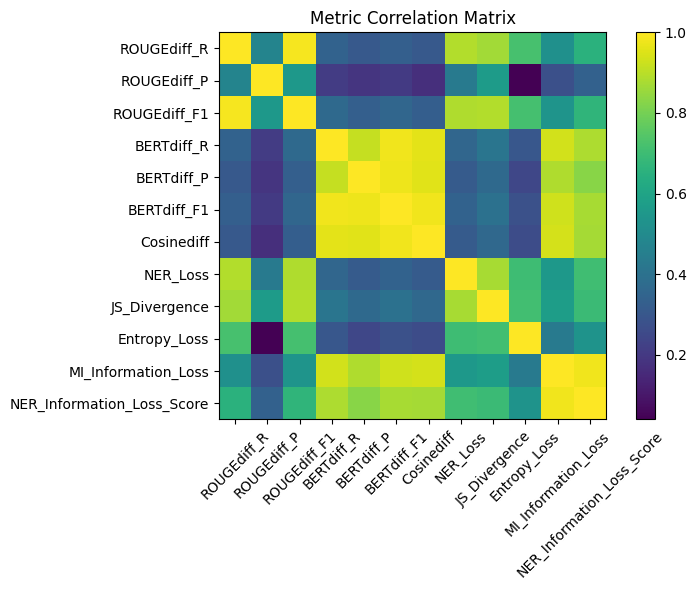

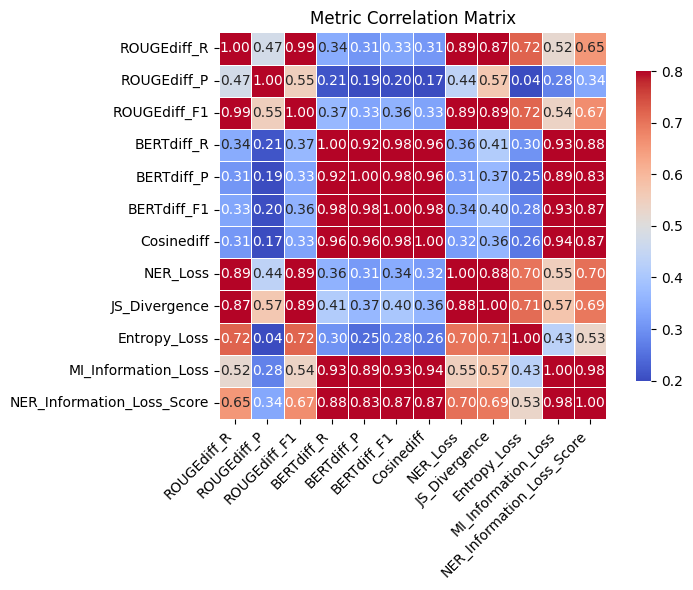

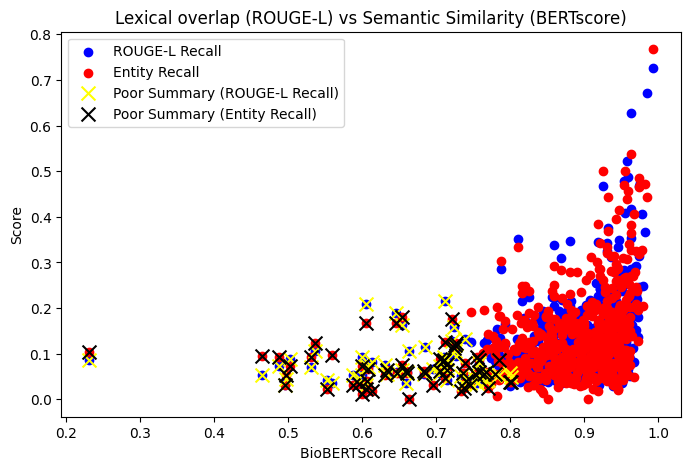

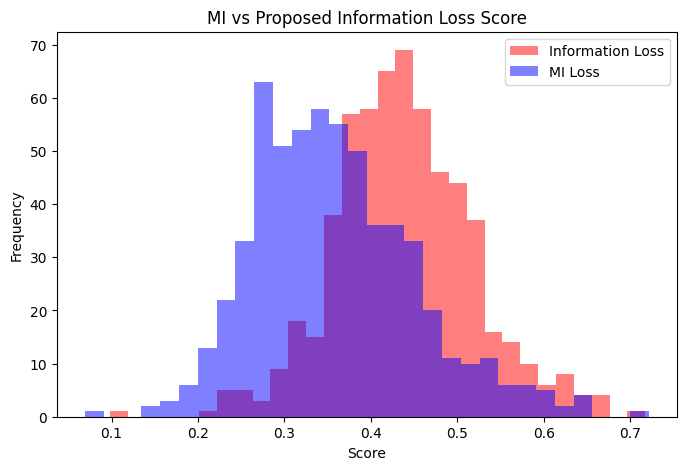

RESULTS SAVED as multiclinsum_information_loss_results.csv


In [14]:

# ==================================================================
# 6 - ANALYSIS
# ==================================================================

#convert ROUGE, BERT and cosine into differences instead of similarities
df['ROUGEdiff_R'] = 1- df['ROUGE_L_R']
df['ROUGEdiff_P'] = 1- df['ROUGE_L_P']
df['ROUGEdiff_F1'] = 1- df['ROUGE_L_F1']
df['BERTdiff_R'] = 1- df['BiomedBERTScore_R']
df['BERTdiff_P'] = 1- df['BiomedBERTScore_P']
df['BERTdiff_F1'] = 1- df['BiomedBERTScore_F1']
df['Cosinediff'] = 1- df['Embedding_Cosine']

#investigate statistics
print("SUMMARY STATISTICS")
metrics = [
    "ROUGEdiff_R",
    "ROUGEdiff_P",
    "ROUGEdiff_F1",
    "BERTdiff_R",
    "BERTdiff_P",
    "BERTdiff_F1",
    "Cosinediff",
    "NER_Loss",
    "JS_Divergence",
    "Entropy_Loss",
    "MI_Information_Loss",
    "NER_Information_Loss_Score"
]
summary_stats = df[metrics].describe()
print(summary_stats)
summary_stats.to_csv('summary_statistics.csv')

# # DETECT HIGH-LOSS SUMMARIES
print("THRESHOLD ANALYSIS")
threshold = df["NER_Information_Loss_Score"].quantile(0.90)
print("High-loss threshold:", threshold)
df["Poor_Summary"] = (df["NER_Information_Loss_Score"] > threshold)
print("Poor summaries detected:", df["Poor_Summary"].sum())


# ==================================================================
# 7 - VISUALISATIONS
# ==================================================================


# METRIC CORRELATION HEATMAP
print("CORRELATION MATRIX")
correlation_matrix = df[metrics].corr()
print(correlation_matrix)

# PLOT
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix)
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)
plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)
plt.colorbar()
plt.title("Metric Correlation Matrix")
plt.tight_layout()
plt.show()

# alternative in seaborn
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,          # show values in cells
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",
    vmin=0.2,            # lower limit
    vmax=0.8,            # upper limit
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.title("Metric Correlation Matrix")
plt.tight_layout()
plt.show()


# BERTScore vs ROUGE-L scores AND Entity Recall
# These are how similar the full reports and summaries are

plt.figure(figsize=(8, 5))
poor = df[df["Poor_Summary"] == True]
plt.scatter(df["BiomedBERTScore_R"], df["ROUGE_L_R"], color="b", label="ROUGE-L Recall")
plt.scatter(df["BiomedBERTScore_R"], df["Entity_Recall"], color="r", label="Entity Recall")
# Highlight poor summaries with black crosses
plt.scatter(poor["BiomedBERTScore_R"], poor["ROUGE_L_R"], color="yellow", marker="x", s=100, label="Poor Summary (ROUGE-L Recall)")
plt.scatter(poor["BiomedBERTScore_R"], poor["Entity_Recall"], color="black", marker="x", s=100, label="Poor Summary (Entity Recall)")
plt.xlabel("BioBERTScore Recall")
plt.ylabel("Score")
plt.title("Lexical overlap (ROUGE-L) vs Semantic Similarity (BERTscore)")
plt.legend()
plt.show()


# # BOXPLOT

# plt.figure(figsize=(6, 5))
# plt.boxplot([
#     df[ df["Poor_Summary"] == False ]["NER_Information_Loss_Score"],
#     df[ df["Poor_Summary"] == True ]["NER_Information_Loss_Score"]
# ])
# plt.xticks([1, 2], ["Good", "Poor"])
# plt.ylabel("Information Loss Score")
# plt.title("Good vs Poor Summaries")
# plt.show()


# HISTOGRAM of BOTH my NER Information Loss Score and MI

plt.figure(figsize=(8, 5))
plt.hist(df["NER_Information_Loss_Score"], bins=30, color="r", label="Information Loss", alpha=0.5 )
plt.hist(df["MI_Information_Loss"], bins=30, color="b", label="MI Loss", alpha=0.5 )
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.title("MI vs Proposed Information Loss Score")
plt.legend()
plt.show()


# ==================================================================
# 8 - EXPORT RESULTS
# ==================================================================

OUTPUT_FILE = "multiclinsum_information_loss_results.csv"
df.to_csv(OUTPUT_FILE, index=False)
print("RESULTS SAVED as", OUTPUT_FILE)
